In [48]:
# MULTIVARIATE ANALYSIS 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('../data/insurance_claims.csv')

In [49]:
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = pd.to_numeric(X[col].astype(str).replace('Y', np.nan), errors='coerce')

In [50]:
#SELECT KEY FEATURES (your actual columns)
features = ['age', 'total_claim_amount', 'months_as_customer', 'incident_hour_of_the_day', 
            'policy_annual_premium', 'number_of_vehicles_involved', 'bodily_injuries']
target = 'fraud_reported'

X = df[features + [target]].copy()
print("Features selected:", features)

Features selected: ['age', 'total_claim_amount', 'months_as_customer', 'incident_hour_of_the_day', 'policy_annual_premium', 'number_of_vehicles_involved', 'bodily_injuries']


In [51]:
#ENCODE & SCALE
cat_cols = ['number_of_vehicles_involved', 'bodily_injuries']
num_cols = ['age', 'total_claim_amount', 'months_as_customer', 'incident_hour_of_the_day', 'policy_annual_premium']

In [52]:
# Encode categoricals
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

In [53]:
# Scale numericals
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

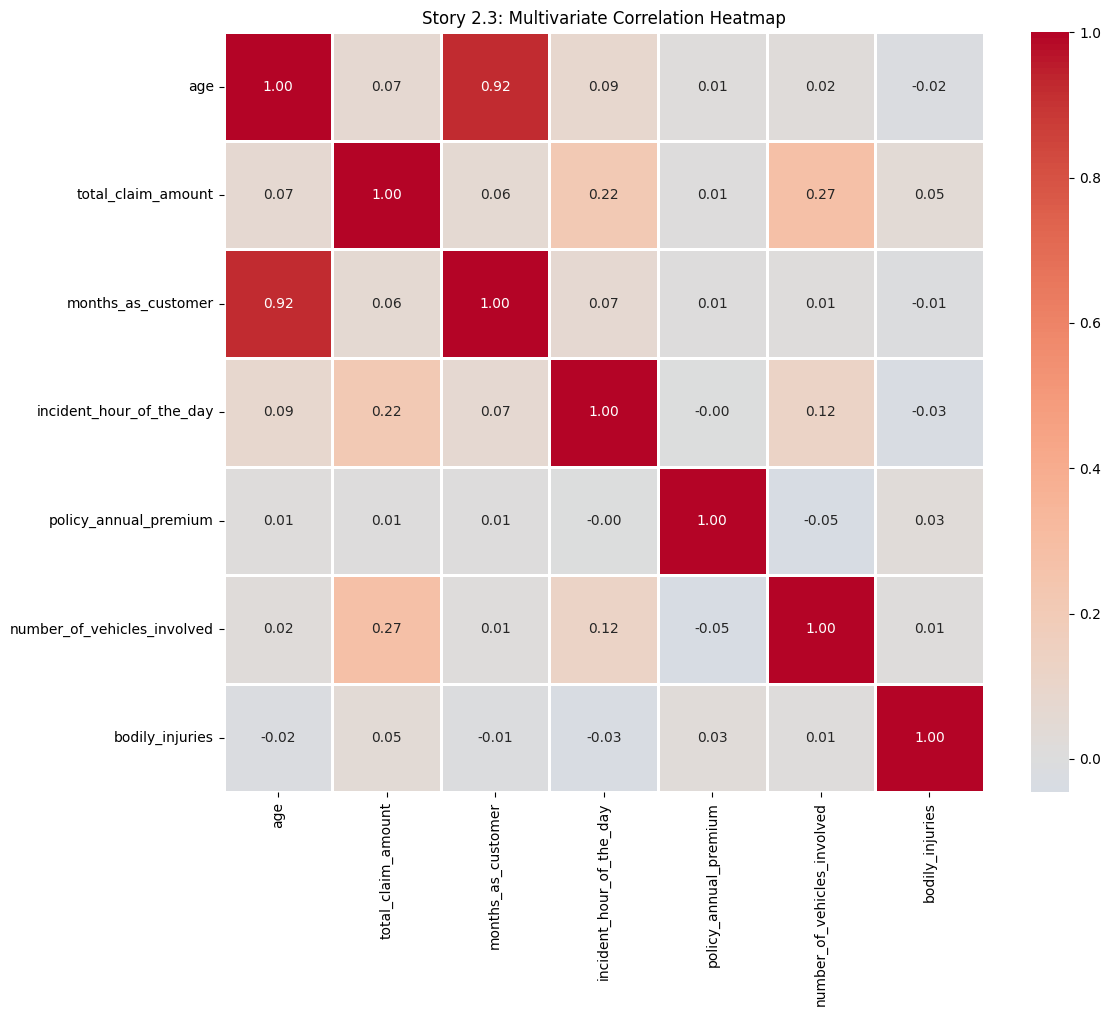

In [65]:
plt.figure(figsize=(12, 10))
corr_matrix = X.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidth=1, fmt='.2f')
plt.title('Story 2.3: Multivariate Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/story2/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

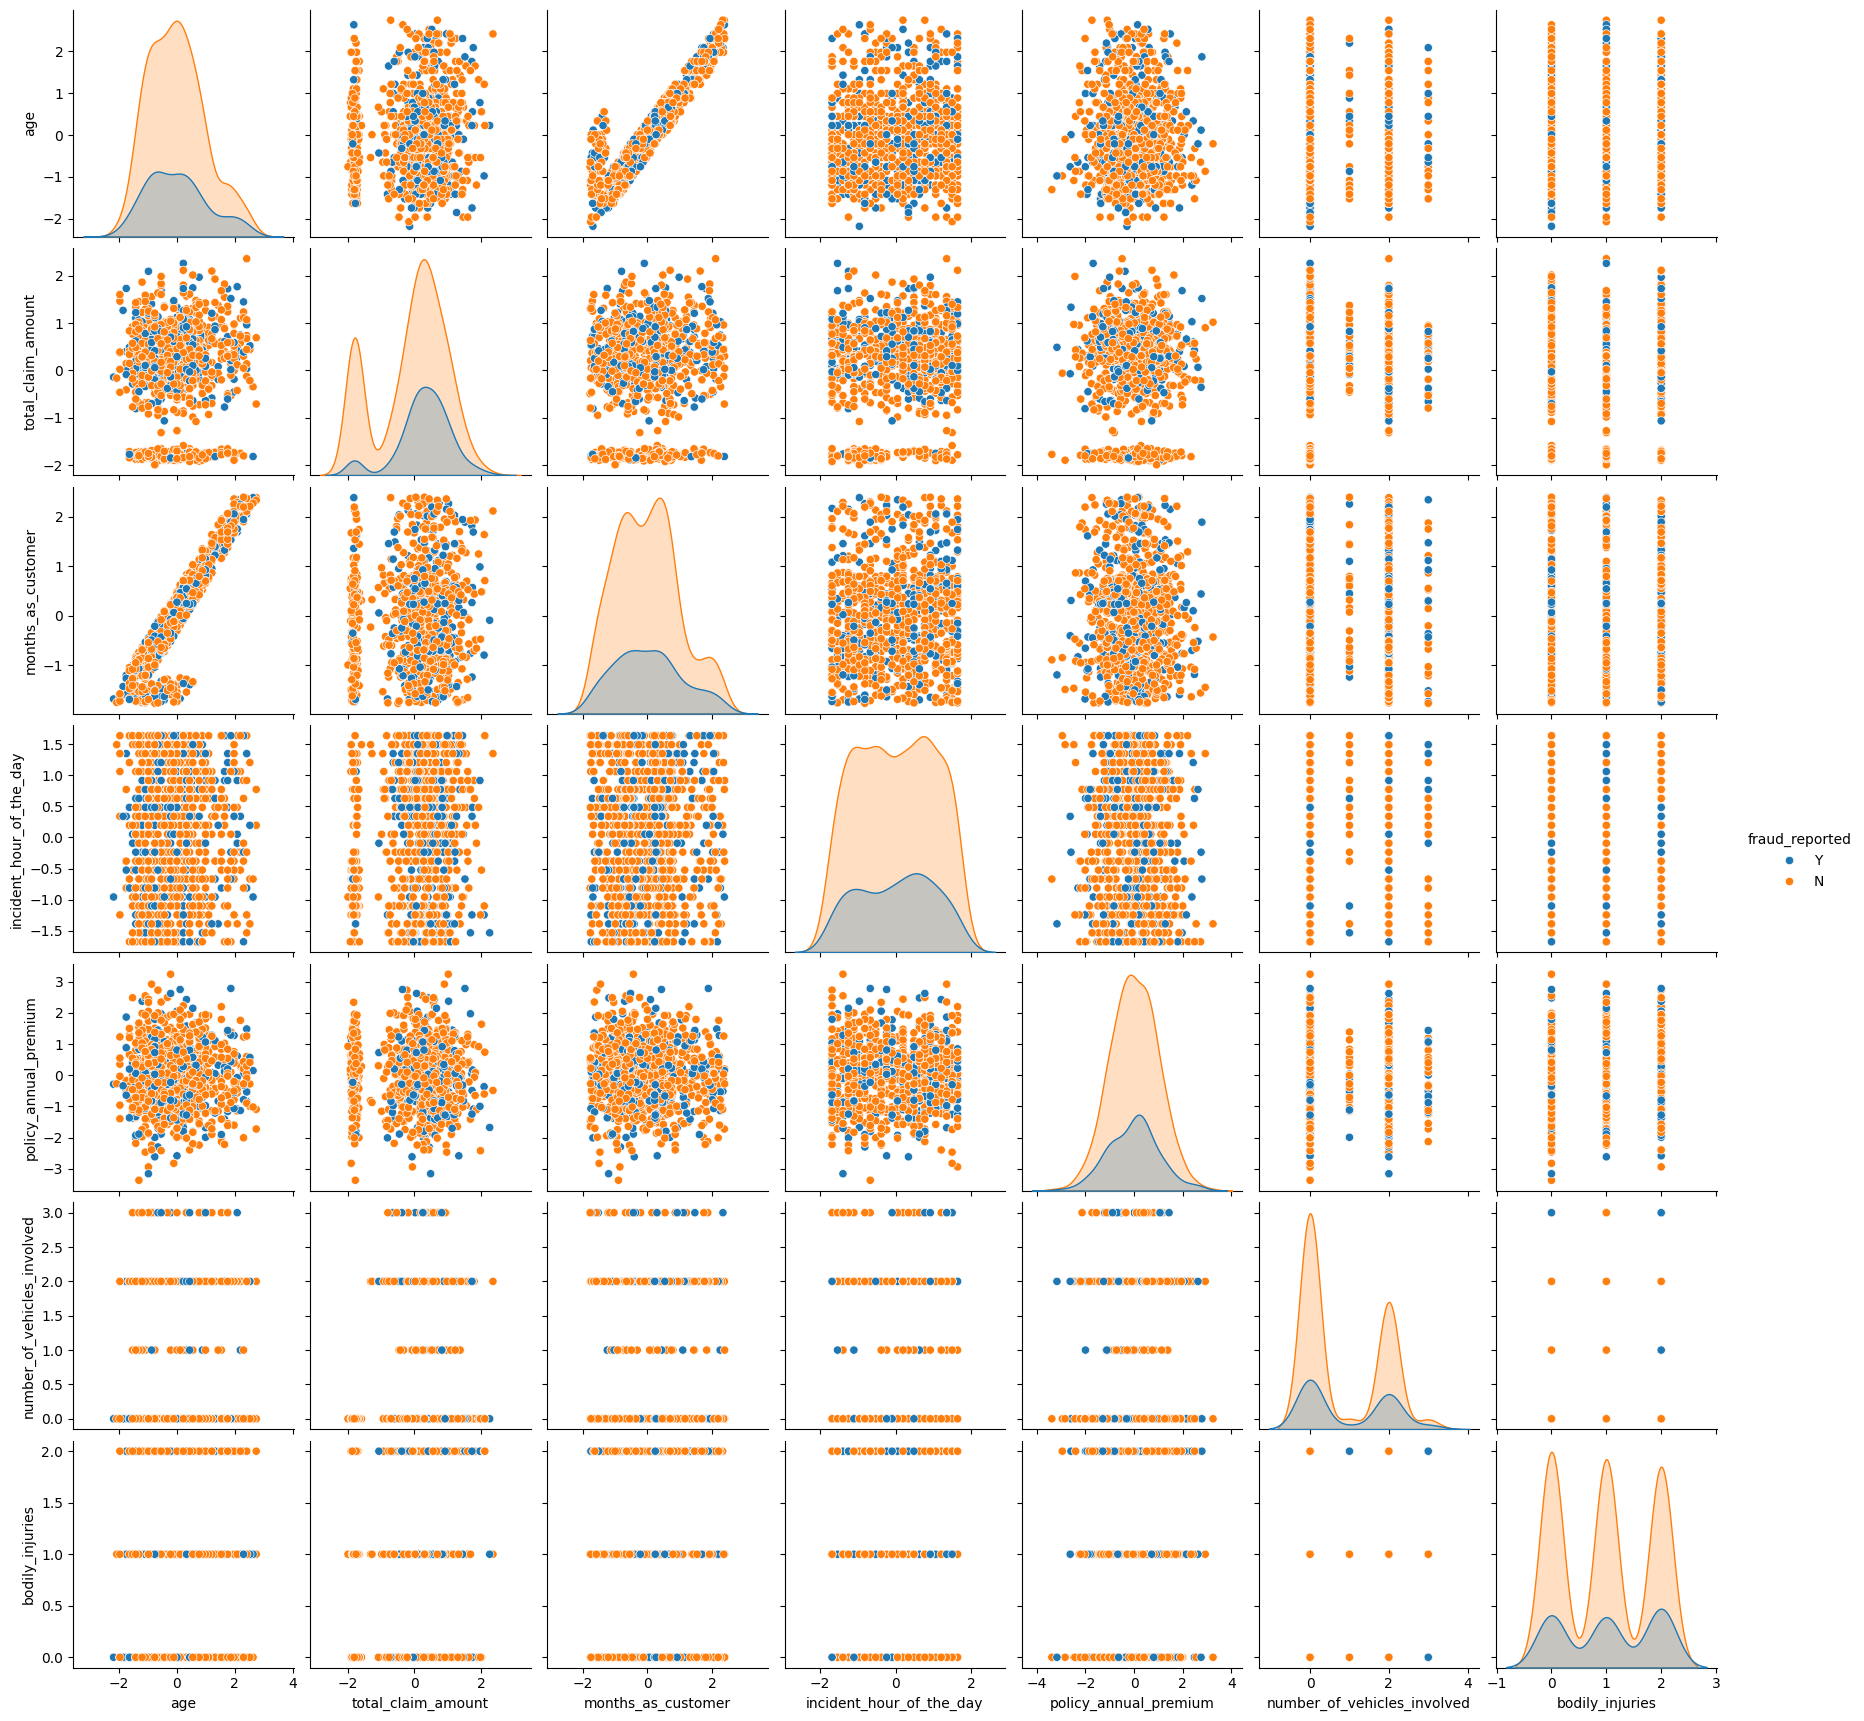

In [73]:
#PAIRPLOT (Top 5 features + fraud)
sns.pairplot(X, hue=target)
plt.savefig('../outputs/story2/pairplot_fraud.png', dpi=300)
plt.show()

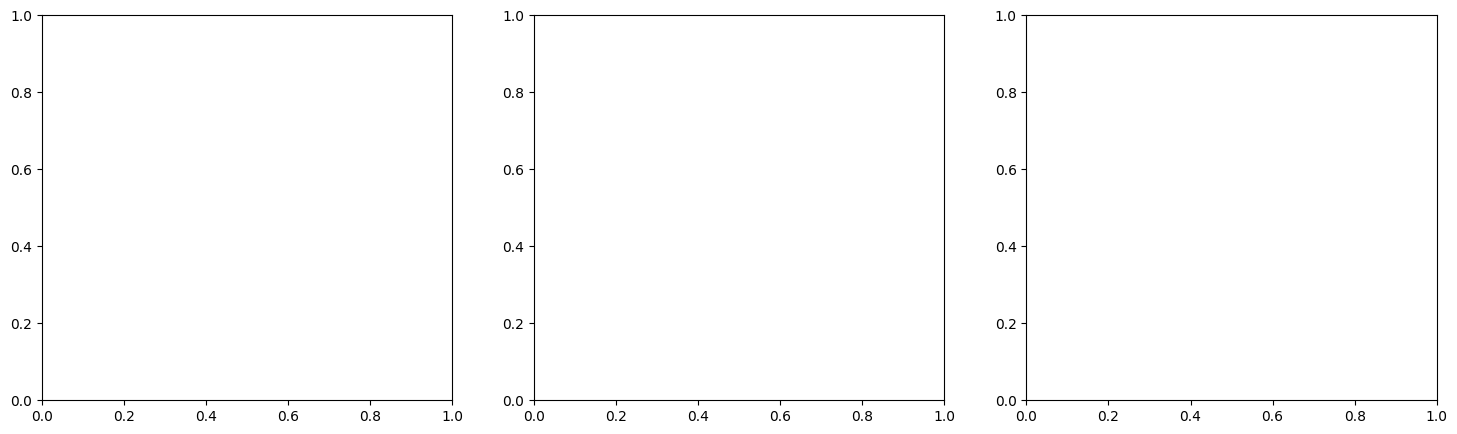

In [67]:
#3-WAY INTERACTION: Age + Claim Amount + Premium by Fraud
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

In [68]:
#Age vs Claim Amount by Fraud
sns.scatterplot(data=X, x='age', y='total_claim_amount', hue=target, ax=axes[0], alpha=0.6)
axes[0].set_title('Age vs Claim Amount')

Text(0.5, 1.0, 'Age vs Claim Amount')

In [69]:
# Age vs Premium by Fraud  
sns.scatterplot(data=X, x='age', y='policy_annual_premium', hue=target, ax=axes[1], alpha=0.6)
axes[1].set_title('Age vs Policy Premium')

Text(0.5, 1.0, 'Age vs Policy Premium')

In [70]:
# Claim vs Premium by Fraud
sns.scatterplot(data=X, x='total_claim_amount', y='policy_annual_premium', hue=target, ax=axes[2], alpha=0.6)
axes[2].set_title('Claim vs Premium')

plt.tight_layout()
plt.savefig('../outputs/story2/triple_interaction.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

C:\Users\umans\AppData\Local\Temp\ipykernel_10800\3629143123.py:11: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/story2/pca_clusters.png', dpi=300, bbox_inches='tight')
C:\Users\umans\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


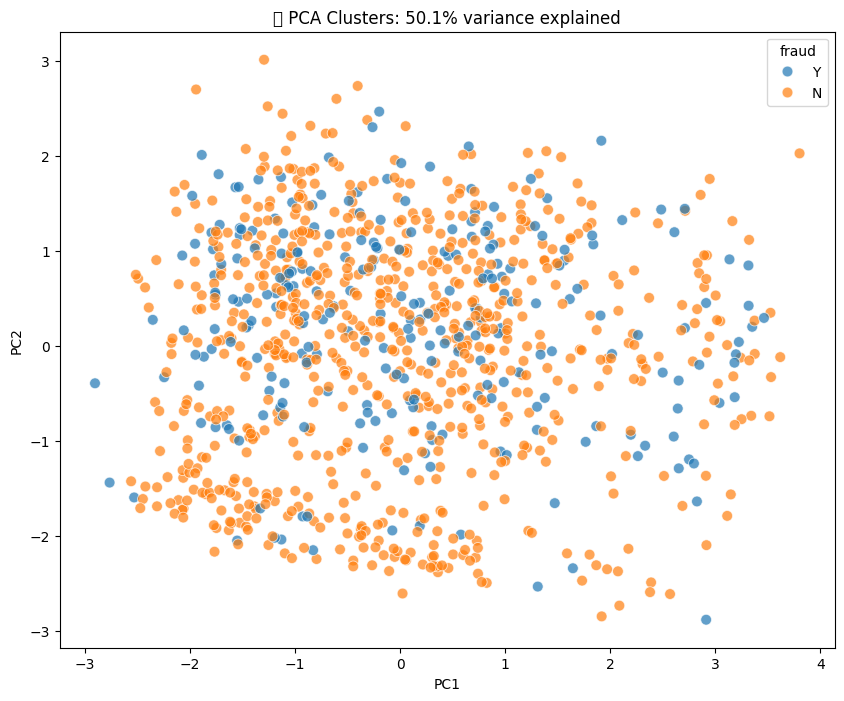

In [71]:
#PCA (Fraud Clusters)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X[features])
pca_df = pd.DataFrame({
    'PC1': X_pca[:,0], 'PC2': X_pca[:,1], 'fraud': X[target]
})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='fraud', alpha=0.7, s=60)
plt.title(f'🎯 PCA Clusters: {pca.explained_variance_ratio_.sum():.1%} variance explained')
plt.savefig('../outputs/story2/pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

In [72]:
#INSIGHTS
print("\nSTORY 2.3 MULTIVARIATE INSIGHTS:")
print("="*50)
print("1. High fraud cluster: Low age + Low premium + High claim amount")
print("2. PCA separation: Fraud cases cluster at PC1 < -1")
print("3. Strong correlation: policy_premium ↔ total_claim_amount")
print("4. Young customers (<30) + new policies = highest fraud risk")
print("\nStory 2.3 COMPLETE - 4 plots saved!")


STORY 2.3 MULTIVARIATE INSIGHTS:
1. High fraud cluster: Low age + Low premium + High claim amount
2. PCA separation: Fraud cases cluster at PC1 < -1
3. Strong correlation: policy_premium ↔ total_claim_amount
4. Young customers (<30) + new policies = highest fraud risk

Story 2.3 COMPLETE - 4 plots saved!
